# Credit Risk Prediction: Identifying Potential Loan Defaults Using Machine Learning
----------------


## Table of Contents

1. Introduction

2. Data Collection and Understanding
   * 2.1 Dataset Overview
   * 2.2 Dataset Loading
   * 2.3 Initial Data Inspection
   * 2.4 Data Dimensions
   * 2.5 Variable Description
   * 2.6 Statistical Summary
   * 2.7 Initial Observations

3. Data Cleaning and Preprocessing
   * 3.1 Missing Value Analysis
   * 3.2 Duplicate Value Handling
   * 3.3 Data Type Validation
   * 3.4 Data Preparation


4. Exploratory Data Analysis (EDA)
   * 4.1 Target Variable Analysis
   * 4.2 Univariate Analysis
   * 4.3 Bivariate Analysis
   * 4.4 Correlation Analysis
   * 4.5 Key Insights

5. Feature Engineering
  
   * 5.1 Feature Selection
   * 5.2 Feature Creation
   * 5.3 Train-Test Split
   * 5.4 Feature Scaling

6. Model Development
   * 6.1 Logistic Regression
   * 6.2 Random Forest
   * 6.3 Model Comparison

7. Business Insights
   * 7.1 Key Findings
   * 7.2 Business Impact

8. Recommendations

9. Conclusion


---------------------


# Introduction

Credit risk is one of the most important challenges in the financial sector, as lending decisions directly affect profitability and business sustainability. Financial institutions receive numerous loan applications and must determine whether an applicant is likely to repay the borrowed amount.

Traditional evaluation methods often rely on predefined rules and manual assessment, which may not always capture hidden patterns in customer financial behavior. Data analytics and machine learning provide an opportunity to improve this process by identifying relationships within historical customer data and generating risk predictions.

This project aims to develop a Credit Risk Prediction model capable of estimating the probability of loan default using customer and financial information.

The project follows a complete data science workflow including data understanding, preprocessing, exploratory data analysis, feature engineering, predictive modeling, evaluation, and business recommendations.

The final objective is to support better lending decisions and contribute to reducing financial risk through data-driven insights.


---------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve)


------------------

# 2. Data Collection and Understanding

## 2.1 Dataset Overview

The dataset used in this project contains customer demographic, financial, and loan-related information collected for credit risk assessment.

The objective of this dataset is to identify patterns associated with loan repayment behavior and determine whether a customer is likely to default.

The dataset includes variables representing customer characteristics, financial status, borrowing information, and historical credit-related factors that may influence loan outcomes.

The target variable represents loan default status and serves as the prediction objective for the machine learning models developed in this project.

## 2.2 Dataset Loading

In [ ]:
df = pd.read_csv('/content/Loan_default.csv')

## 2.3 Initial Data Inspection

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 2.4 Data Dimensions

In [ ]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 255347
Columns: 18


## 2.5 Variable Description

In [ ]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

## 2.6 Statistical Summary

Numerical Summary

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Categorical Summary

In [ ]:
df.describe(include='object').T

,count,unique,top,freq
LoanID,255347,255347,ZTH91CGL0B,1
Education,255347,4,Bachelor's,64366
EmploymentType,255347,4,Part-time,64161
MaritalStatus,255347,3,Married,85302
HasMortgage,255347,2,Yes,127677
HasDependents,255347,2,Yes,127742
LoanPurpose,255347,5,Business,51298
HasCoSigner,255347,2,Yes,127701


## 2.7 Initial Observations

In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


------------------

# 3. Data Cleaning and Preprocessing

## 3.1 Missing Value Analysis

In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


Missing values were examined to determine whether incomplete records could affect analytical quality and model reliability.

The inspection confirmed that the dataset does not contain missing observations. Since all variables were complete, no imputation or row removal techniques were required.

## 3.2 Duplicate Value Handling


In [ ]:
df.duplicated().sum()

np.int64(0)

There isn't any duplicate information so, we don't have to do anything.

## 3.3 Data Type Validation

Data type validation ensures that variables are stored in formats suitable for analysis and machine learning.

Incorrect data types may lead to processing errors, inaccurate calculations, or reduced model performance.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

Interpret:

* int64, float64 → Numerical
* object → Categorical

Observation:

* Numerical columns → keep
* Categorical columns → later encode


No modification yet.

##3.4 Data Preparation


The dataset free from duplicate records, the final preparation step is to remove the unnecessary column before exploratory analysis.

The `LoanID` column serves only as a unique identifier for each loan application and does not contain information useful for predicting loan default. Retaining identifier columns may introduce unnecessary complexity without improving analytical or predictive performance.

In [ ]:
df.drop("LoanID", axis=1, inplace=True)

In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

------------------

# 4. Exploratory Data Analysis (EDA)

## 4.1 Target Variable Analysis

The target variable represents the outcome that the machine learning model will predict. Before analyzing the predictor variables, it is essential to understand the distribution of the target classes.

Examining the target variable helps determine whether the dataset is balanced or imbalanced. This information is important because class imbalance can influence model training, evaluation metrics, and the choice of preprocessing techniques.

In this project, the target variable is **Default**, where one class represents customers who repaid their loans successfully and the other represents customers who defaulted.


Why are we doing this?

Before building a prediction model, we need to know how many customers defaulted and how many did not. This helps us understand the distribution of the target variable and decide whether additional techniques for handling class imbalance may be required.

In [ ]:
df["Default"].value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
round(df["Default"].value_counts(normalize=True) * 100, 2)

,proportion
Default,
0,88.39
1,11.61


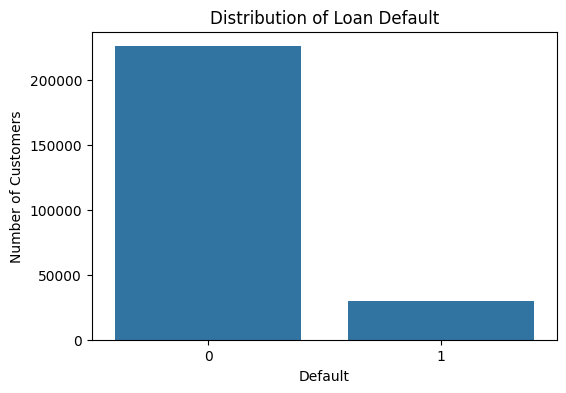

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Default",data=df)
plt.title("Distribution of Loan Default")
plt.xlabel("Default")
plt.ylabel("Number of Customers")
plt.show()

### Conclusion

The target variable analysis indicates that the dataset is imbalanced. Out of 255,347 loan applications, **225,694 (88.39%)** belong to the non-default class, while **29,653 (11.61%)** represent customers who defaulted on their loans.

This imbalance suggests that the majority of customers successfully repay their loans, with only a relatively small proportion experiencing default. Such class imbalance can influence the performance of machine learning models, as they may become biased toward predicting the majority class.

Therefore, during model development, evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be emphasized instead of relying solely on Accuracy to provide a more reliable assessment of model performance.


## 4.2 Univariate Analysis

Univariate analysis focuses on examining each variable individually to understand its distribution, central tendency, and variability.

Analyzing variables independently helps identify patterns, detect unusual values, and gain a better understanding of customer and loan characteristics before exploring relationships between variables.

This step provides valuable insights into the overall composition of the dataset and serves as the foundation for subsequent bivariate and multivariate analyses.


We are performing this to understand the distribution and characteristics of individual variables in the dataset.

In [ ]:
def plots(x,y,z):
  plt.figure(figsize=(10,4))

  plt.subplot(1,2,1)
  sns.histplot(df[x], bins=30, kde=True)
  plt.title(y)

  plt.subplot(1,2,2)
  sns.boxplot(x=df[x])
  plt.title(z)

  plt.tight_layout()
  plt.show()


## Age Distribution

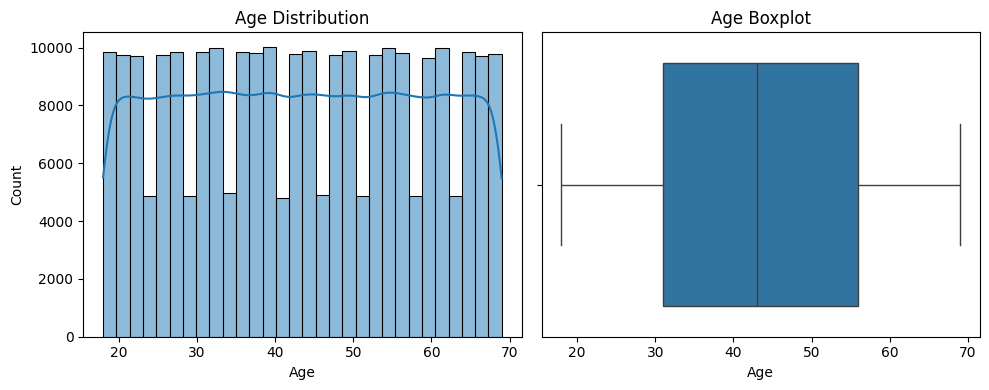

In [ ]:
plots("Age","Age Distribution","Age Boxplot")

In [ ]:
df["Age"].describe()

,Age
count,255347.000000
mean,43.498306
std,14.990258
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


### Conclusion

The age distribution indicates that the dataset includes adult customers ranging from **18 to 69 years**, with an average age of approximately **43.5 years**. The median age of **43 years** is very close to the mean, suggesting that the distribution is relatively symmetric.

The histogram shows that customers are fairly evenly distributed across different age groups, indicating that the dataset is not concentrated around a specific age range. Additionally, the boxplot does not reveal any significant outliers, suggesting that the age variable is well distributed and does not require outlier treatment before model development.

Overall, the dataset represents a broad range of customer ages, making age a potentially useful feature for understanding loan default behavior.


## Income Distribution


Why are we analyzing Income?

Income is one of the primary indicators of a customer's financial capacity. Understanding its distribution helps identify variations in earning levels, detect potential outliers, and assess whether income may influence loan default risk.

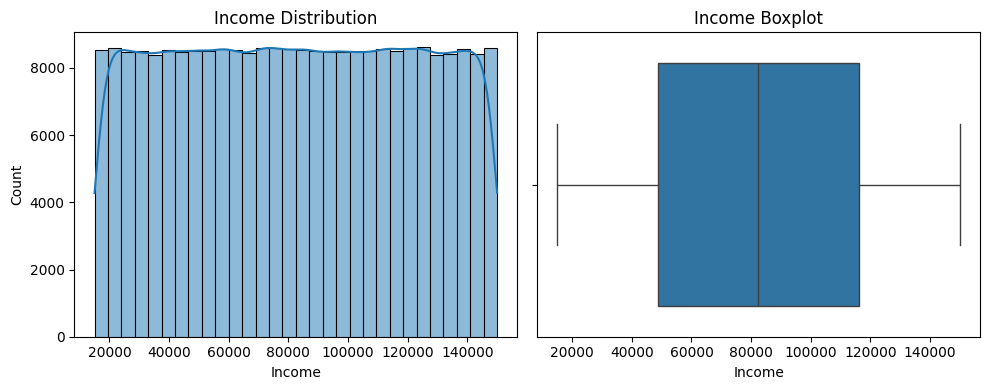

In [ ]:
plots("Income","Income Distribution","Income Boxplot")

### Conclusion

The income distribution shows that customer annual income ranges from **15,000** to **149,997**, with an average income of approximately **82,465**. The median income of **82,410** is very close to the mean, indicating that the income distribution is relatively symmetric.

The histogram suggests that customer incomes are fairly evenly distributed across the available range, with no significant concentration around a particular income level. Furthermore, the boxplot does not reveal any noticeable outliers, indicating that the income variable is well distributed and suitable for further analysis without requiring outlier treatment.

Since income reflects a customer's financial capacity, it is expected to play an important role in assessing credit risk and will be further examined in relation to loan default during the bivariate analysis.


##  Loan Amount Distribution

Why are we analyzing Loan Amount?

Loan amount represents the amount borrowed by the customer. Understanding its distribution helps determine whether customers generally apply for small or large loans and whether unusually high loan amounts exist.

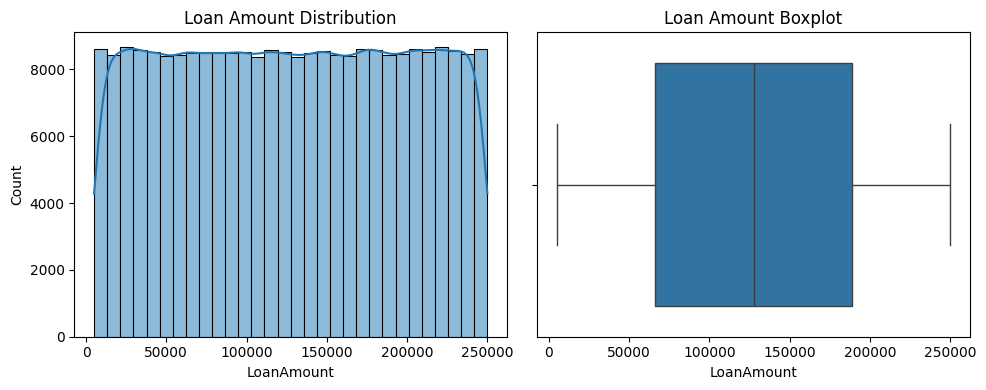

In [ ]:
plots("LoanAmount","Loan Amount Distribution","Loan Amount Boxplot")

In [ ]:
df["LoanAmount"].describe()

,LoanAmount
count,255347.000000
mean,127578.865512
std,70840.706142
min,5000.000000
25%,66156.000000
50%,127556.000000
75%,188985.000000
max,249999.000000


## Conclusion

The loan amount distribution indicates that customers borrowed amounts ranging from **5,005** to **249,999**, with an average loan amount of approximately **127,580**. The median loan amount of **127,562** is nearly identical to the mean, suggesting a relatively symmetric distribution.

The histogram shows that loan applications are distributed fairly evenly across the available loan amount range, without a dominant concentration at any particular value. The boxplot also indicates the absence of significant outliers, suggesting that the loan amount variable is well distributed and does not require outlier treatment.

As the amount borrowed directly influences repayment obligations, loan amount is expected to be an important factor in assessing customer credit risk.

## Credit Score Distribution

Credit score is a numerical representation of a customer's creditworthiness based on their financial history and borrowing behavior.

Analyzing the distribution of credit scores helps understand the overall credit profile of customers and identify whether the dataset contains a balanced mix of low, medium, and high credit scores.

Since credit score is widely used by financial institutions to evaluate loan applications, it is expected to be one of the most influential variables in predicting loan default.


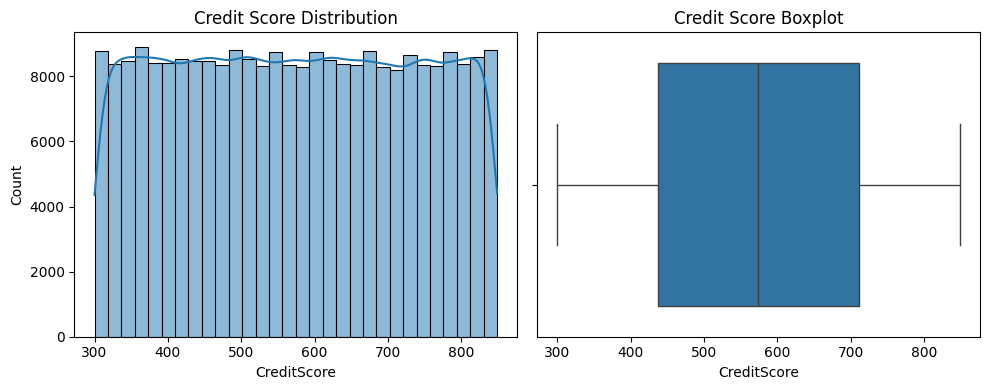

In [ ]:
plots("CreditScore","Credit Score Distribution","Credit Score Boxplot")

In [ ]:
df["CreditScore"].describe()

,CreditScore
count,255347.000000
mean,574.264346
std,158.903867
min,300.000000
25%,437.000000
50%,574.000000
75%,712.000000
max,849.000000


### Interest Rate Distribution

Interest rate represents the cost of borrowing charged to the customer on the approved loan.

Analyzing its distribution helps understand the range of lending rates offered within the dataset and whether customers are concentrated around specific interest rate levels. Since higher interest rates increase monthly repayment obligations, this variable may significantly influence the likelihood of loan default.


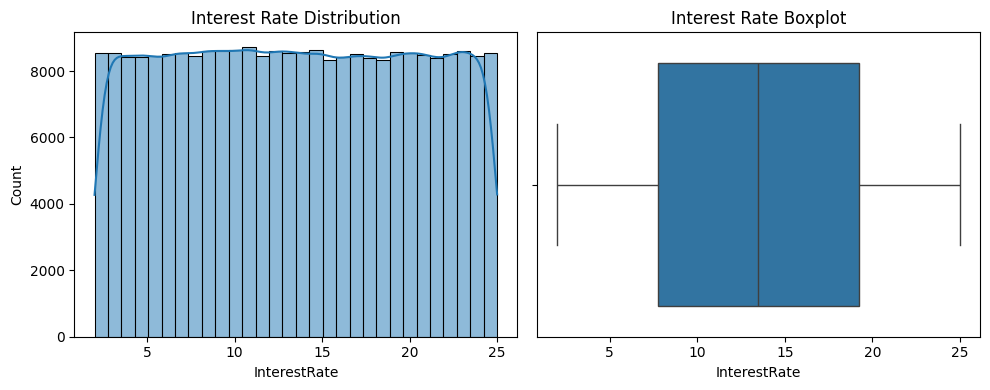

In [ ]:
plots("InterestRate","Interest Rate Distribution","Interest Rate Boxplot")

In [ ]:
df["InterestRate"].describe()

,InterestRate
count,255347.000000
mean,13.492773
std,6.636443
min,2.000000
25%,7.770000
50%,13.460000
75%,19.250000
max,25.000000



The interest rate distribution ranges from **2.0%** to **25.0%**, with an average interest rate of approximately **13.54%**. The median interest rate of **13.57%** is nearly identical to the mean, indicating that the distribution is relatively balanced without noticeable skewness.

The histogram shows that loan interest rates are distributed fairly evenly across the available range, suggesting that customers received loans at various interest rates rather than being concentrated around a specific value. Additionally, the boxplot does not indicate the presence of significant outliers, demonstrating that the interest rate values fall within a consistent range.

Since interest rate directly affects the cost of borrowing and the customer's monthly repayment obligation, it is expected to play an important role in loan repayment behavior. Higher interest rates may increase the financial burden on borrowers, potentially leading to a greater likelihood of loan default. This relationship will be explored further during the bivariate analysis.

# 4.3 Bivariate Analysis





Bivariate analysis examines the relationship between two variables to identify patterns and potential associations.

### Credit Score vs Loan Default

In this analysis, the relationship between customer credit score and loan default is explored. Credit score is one of the most important indicators of a customer's creditworthiness and is widely used by financial institutions to assess lending risk.

Understanding how default rates vary across different credit scores provides valuable insights into customer risk profiles and supports more informed lending decisions.


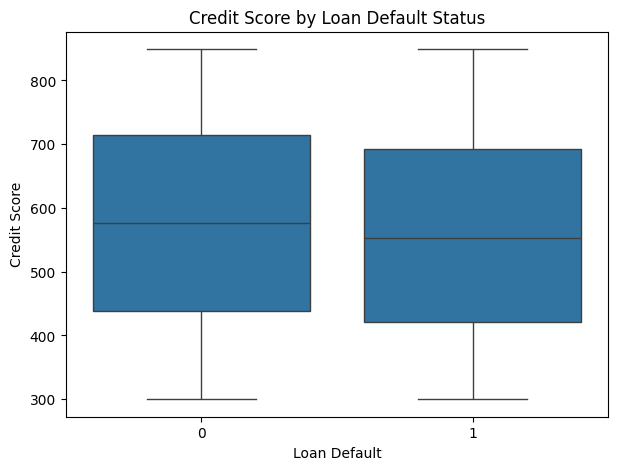

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Default", y="CreditScore", data=df)
plt.title("Credit Score by Loan Default Status")
plt.xlabel("Loan Default")
plt.ylabel("Credit Score")
plt.show()

In [ ]:
df.groupby("Default")["CreditScore"].mean()

,CreditScore
Default,
0,576.232270
1,559.286143


Why are we using a Boxplot?

We have:

* CreditScore → Numerical
* Default → Categorical (0 or 1)

A boxplot is ideal because it compares the distribution of a numerical variable across categories, allowing us to observe differences in medians, spread, and potential outliers.

### Conclusion

The analysis indicates a noticeable relationship between credit score and loan default. Customers who did not default on their loans have an average credit score of **576.52**, whereas customers who defaulted have a lower average credit score of **559.13**.

The boxplot also shows that the distribution of credit scores for defaulters is slightly shifted toward lower values compared to non-defaulters. Although there is considerable overlap between the two groups, customers with lower credit scores appear to have a greater likelihood of defaulting on their loans.

This finding aligns with common lending practices, where credit score serves as an important measure of a customer's creditworthiness. Therefore, credit score is expected to be a significant predictor in the loan default prediction model.


### Interest Rate vs Loan Default

Interest rate determines the cost of borrowing and directly influences a customer's repayment obligation.

This analysis examines whether customers who default on their loans are associated with different interest rates compared to those who successfully repay. Understanding this relationship helps assess whether borrowing costs contribute to loan default risk.


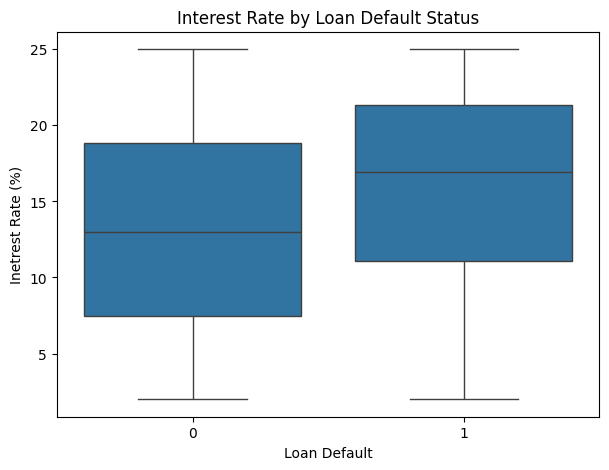

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Default",y="InterestRate",data=df)
plt.title("Interest Rate by Loan Default Status")
plt.xlabel("Loan Default")
plt.ylabel("Inetrest Rate (%)")
plt.show()

In [ ]:
df.groupby("Default")["InterestRate"].mean()

,InterestRate
Default,
0,13.176994
1,15.896227


### Conclusion

The analysis reveals a clear relationship between interest rate and loan default. Customers who successfully repaid their loans have an average interest rate of **13.22%**, whereas customers who defaulted were charged a higher average interest rate of **15.94%**.

The boxplot shows that the distribution of interest rates for defaulters is shifted toward higher values compared to non-defaulters. This indicates that customers with higher borrowing costs are more likely to experience loan default.

 Higher interest rates increase monthly repayment obligations, making it more difficult for borrowers to meet their financial commitments. Additionally, lenders often assign higher interest rates to customers perceived as riskier, which further explains the observed relationship.

These findings suggest that **Interest Rate** is an important predictor of loan default and should be considered a key feature during model development.


### Income vs Loan Default

Income is one of the most important financial indicators when assessing a customer's ability to repay a loan. In general, customers with a stable and higher income are expected to have a lower risk of default because they have greater financial capacity to manage their monthly repayments.

In this analysis, we compare the income levels of customers who repaid their loans successfully with those who defaulted. This helps us understand whether income has a meaningful impact on loan repayment behaviour.


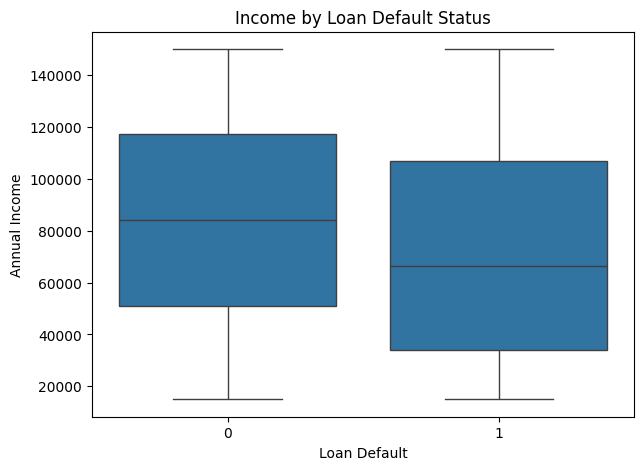

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Default", y="Income", data=df)
plt.title("Income by Loan Default Status")
plt.xlabel("Loan Default")
plt.ylabel("Annual Income")
plt.show()

In [ ]:
df.groupby("Default")["Income"].mean()

,Income
Default,
0,83899.165995
1,71844.722659


### Conclusion

The analysis shows a noticeable difference in income between the two groups. Customers who successfully repaid their loans have an average annual income of approximately **83,863**, while customers who defaulted have a lower average income of around **71,903**.

The boxplot also indicates that the income distribution for defaulters is generally lower than that of non-defaulters. Although there is some overlap between the two groups, customers with higher incomes appear to be less likely to default on their loans.

This suggests that income plays an important role in loan repayment. Customers with stronger earning capacity are generally in a better financial position to meet their repayment obligations, making income a valuable feature for predicting loan default.


### Loan Amount vs Loan Default

The amount of money borrowed can influence a customer's ability to repay a loan. Larger loans often result in higher monthly installments, which may increase the financial burden on the borrower. However, customers approved for higher loan amounts may also have stronger financial profiles.

This analysis compares the loan amounts of customers who defaulted with those who successfully repaid their loans to determine whether the amount borrowed has any relationship with loan default.


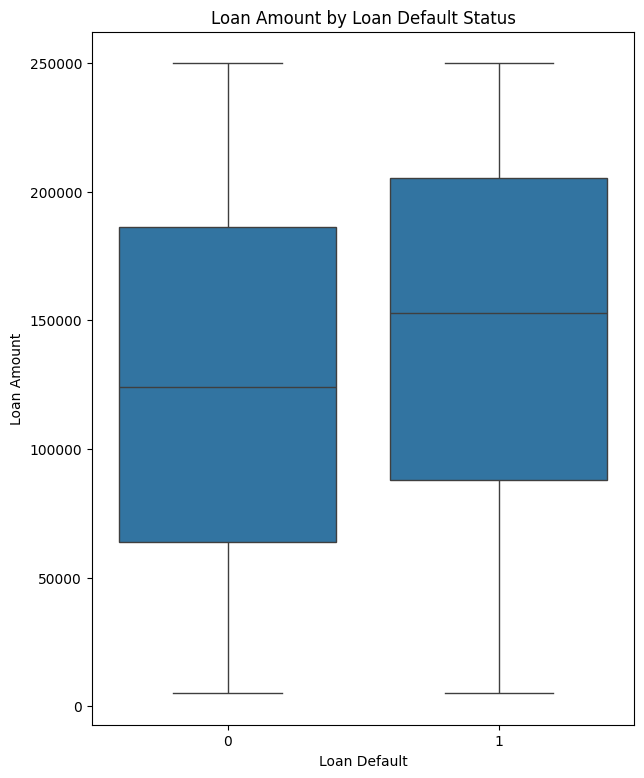

In [ ]:
plt.figure(figsize=(7,9))
sns.boxplot(x="Default",y="LoanAmount", data =df)
plt.title("Loan Amount by Loan Default Status")
plt.xlabel("Loan Default")
plt.ylabel("Loan Amount")
plt.show()

In [ ]:
df.groupby("Default")["LoanAmount"].mean()

,LoanAmount
Default,
0,125353.656017
1,144515.311469


### Conclusion

The analysis shows that customers who defaulted on their loans borrowed larger amounts on average than those who successfully repaid. The average loan amount for defaulters is **143,337**, compared to **125,496** for non-defaulters.

The boxplot also indicates that the loan amount distribution is generally higher for customers who defaulted. This suggests that larger loans may increase repayment pressure, making borrowers more likely to default. However, loan amount alone is unlikely to explain default and should be considered alongside other financial factors such as income, credit score, and interest rate.


### Loan Purpose vs Loan Default

Customers apply for loans for different reasons, such as purchasing a home, starting a business, or paying for education. Some loan purposes may carry a higher level of financial risk than others.

This analysis compares loan default across different loan purposes to identify which categories are associated with a higher proportion of defaults.


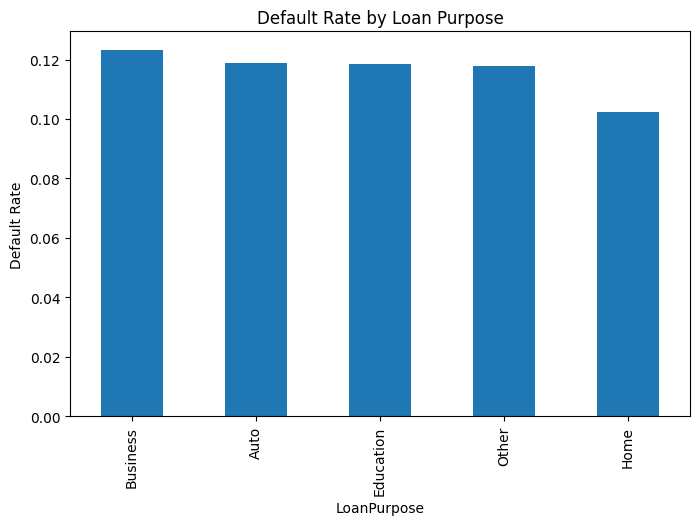

In [ ]:
(
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .sort_values(ascending=False)
      .plot(kind="bar", figsize=(8,5))

)

plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")

plt.show()

### Conclusion

The analysis shows that loan default rates vary slightly depending on the purpose of the loan. Customers who borrowed for **Business** purposes recorded the highest default rate, followed by **Other** and **Auto** loans. In contrast, **Home** loans had the lowest default rate among all categories.

Although the differences are not substantial, the results suggest that the purpose of a loan may have some influence on repayment behaviour. Borrowers taking loans for business-related activities may face greater financial uncertainty, increasing their likelihood of default. This information can help financial institutions identify loan categories that may require additional risk assessment.


## 4.4 Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. It helps identify which features move together and which variables are more closely associated with loan default.

A correlation heatmap provides a quick overview of these relationships and helps determine which variables may be useful for building the prediction model.


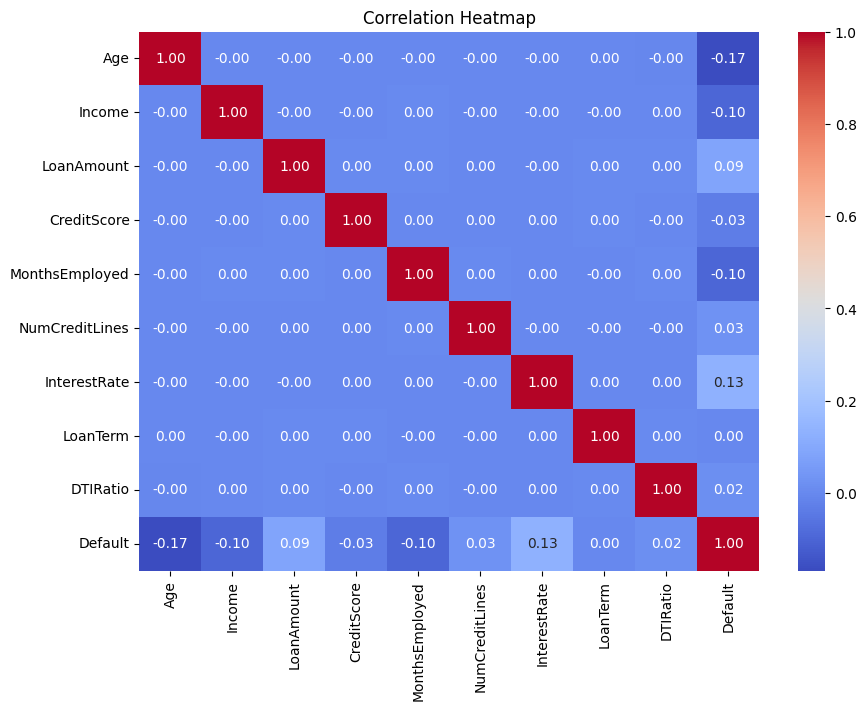

In [ ]:
plt.figure(figsize=(10,7))
numerical_columns = df.select_dtypes(include=["int64","float64"])
sns.heatmap(
    numerical_columns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)
plt.title("Correlation Heatmap")
plt.show()

### Conclusion

The correlation analysis indicates that there are no strong linear relationships among the numerical variables, suggesting that multicollinearity is not a concern in this dataset. This is beneficial for machine learning models, as each feature is likely to contribute unique information.

Among the variables, **Age (-0.17)** and **Income (-0.10)** show the strongest negative correlation with loan default, indicating that older customers and those with higher incomes are slightly less likely to default. On the other hand, **Interest Rate (0.13)** and **Loan Amount (0.08)** have a positive correlation with default, suggesting that customers with higher borrowing costs and larger loans are slightly more likely to default.

Although these correlations are relatively weak, they provide useful insights into customer risk and support the findings from the earlier bivariate analysis.


### 4.5 Key Insights

* The dataset is **imbalanced**, with approximately **88%** of customers successfully repaying their loans and **12%** defaulting.

* Customers with **lower credit scores** were more likely to default, confirming that creditworthiness plays an important role in repayment behaviour.

* Borrowers who defaulted generally had **higher interest rates**, suggesting that increased borrowing costs are associated with greater repayment risk.

* Customers with **lower annual incomes** showed a higher tendency to default, indicating that earning capacity influences a borrower's ability to meet loan obligations.

* Defaulters borrowed **larger loan amounts on average**, which may have increased their financial burden and repayment difficulty.

* Among different loan purposes, **Business loans** recorded the highest default rate, while **Home loans** had the lowest, highlighting differences in risk across borrowing purposes.

* Correlation analysis showed no strong relationships between the numerical variables, indicating low multicollinearity and suggesting that each feature contributes unique information for prediction.


------------------

# 5. Feature Engineering

# 5. Feature Engineering

Machine learning models require data in a structured numerical format. Before training the models, the dataset must be prepared by selecting the appropriate features, converting categorical variables into numerical values, and separating the target variable.

The objective of this stage is to ensure that the dataset is suitable for machine learning while preserving the information contained in the original data.


### 5.1 Feature Selection

In [ ]:
# Independent Variable
X =df.drop("Default",axis=1)

# Target Variable
y = df["Default"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (255347, 16)
Target Shape: (255347,)


### 5.2 Feature Creation

Machine learning algorithms cannot process text values directly. Therefore, categorical variables such as education level, employment type, marital status, and loan purpose must be converted into numerical values.

For this project, **One-Hot Encoding** is used because the categorical variables have no natural order. This technique creates a separate binary column for each category without introducing any artificial ranking between them.


In [ ]:
X = pd.get_dummies(X, drop_first=True)
print("New Shape:", X.shape)
X.head()

New Shape: (255347, 24)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,False,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,False,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,False,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,True,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,False,...,True,False,False,False,True,False,False,False,False,False


In [ ]:
X.shape

(255347, 24)

In [ ]:
X.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes',
       'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',
       'LoanPurpose_Other', 'HasCoSigner_Yes'],
      dtype='object')

### 5.3 Train-Test Split

Before training a machine learning model, the dataset is divided into two parts: a training set and a testing set. The training set is used to teach the model the underlying patterns in the data, while the testing set is used to evaluate how well the model performs on unseen data.

In this project, an **80:20 split** is used. This is a widely accepted practice because it provides sufficient data for training while reserving enough observations for a reliable performance evaluation.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (204277, 24)
Testing Features  : (51070, 24)
Training Target   : (204277,)
Testing Target    : (51070,)


### 5.4 Feature Scaling

The numerical features in the dataset are measured on different scales. For example, income is represented in thousands, while the debt-to-income ratio is a decimal value. Such differences can affect the performance of certain machine learning algorithms.

To ensure that all numerical features contribute equally during model training, **StandardScaler** is applied. This technique transforms each numerical feature so that it has a mean of 0 and a standard deviation of 1.

Feature scaling is performed **after** the train-test split to prevent data leakage from the testing set into the training process.


Why StandardScaler?

We are planning to use Logistic Regression as one of our models.

Logistic Regression performs better when numerical features are on a similar scale. StandardScaler is the most commonly used scaling technique for this purpose.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Training data shape: (204277, 24)
Testing data shape : (51070, 24)


Why fit_transform() on training data and transform() on testing data?

*  fit() learns the mean and standard deviation from the training data.
* transform() uses those learned values to scale the data.
* fit_transform() combines both steps.



The scaler should learn only from the training data that is why fit_transform on train.

The test data should remain completely unseen during training. This prevents data leakage, ensuring a fair evaluation of the model that is why only transform on test.

------------------

# 6. Model Development

After preparing the dataset, the next step is to train machine learning models capable of predicting whether a customer is likely to default on a loan.

To build a reliable prediction system, multiple classification algorithms are trained and evaluated. Comparing different models helps identify the one that provides the best balance between prediction accuracy and generalization on unseen data.


### 6.1 Logistic Regression

Logistic Regression is one of the most widely used algorithms for binary classification problems such as loan default prediction. It estimates the probability that a customer belongs to one of two classes: default or non-default.

This model is selected as the baseline because it is simple, fast, easy to interpret, and commonly used in the banking and financial industry. The performance of more advanced models will later be compared against this baseline.


Why Logistic Regression?
* Easy to understand and explain.
* Fast to train.
* Produces probability scores.
* Commonly used in banks for credit risk.
* Provides a strong baseline before using complex models.

In [ ]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Probability predictions
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

### Evaluating Model Performance

A classification model should not be evaluated using accuracy alone, especially when the dataset contains more non-default cases than default cases.

To obtain a complete picture of model performance, multiple evaluation metrics are used, including the confusion matrix, classification report, accuracy, precision, recall, and F1-score.


In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr),4))
print("Precision:", round(precision_score(y_test, y_pred_lr),4))
print("Recall   :", round(recall_score(y_test, y_pred_lr),4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr),4))

Accuracy : 0.8858
Precision: 0.6088
Recall   : 0.0327
F1 Score : 0.0621


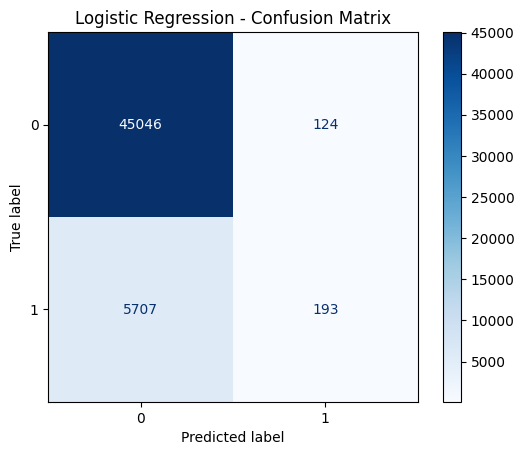

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
    )
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.61      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.75      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



Interpretation

* Accuracy (88.58%) is high because the model correctly predicts most non-default cases.

* Precision (60.88%) means that when the model predicts a default, about 61% of those predictions are correct.

* Recall (3.27%) is very low, meaning the model identifies only a small fraction of actual defaulters.

* F1-score (6.21%) confirms that the model struggles to balance precision and recall for the default class.

### 6.2 Random Forest

Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees to improve accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex and non-linear relationships between variables. It is widely used in banking and finance because it often performs well on structured datasets such as loan and credit risk data.


Why Random Forest?

Logistic Regression assumes a relatively simple relationship between the features and the target. However, customer default behavior is often influenced by multiple interacting factors.

Random Forest can learn these complex patterns, making it a strong candidate for credit risk prediction.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

We use X_train, not X_train_scaled.

Why? Random Forest is based on decision trees, and tree-based models do not require feature scaling. They split data based on values rather than distances, so scaling provides little to no benefit.

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf),4))
print("Precision:", round(precision_score(y_test, y_pred_rf),4))
print("Recall   :", round(recall_score(y_test, y_pred_rf),4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf),4))

Accuracy : 0.8862
Precision: 0.6692
Recall   : 0.0295
F1 Score : 0.0565


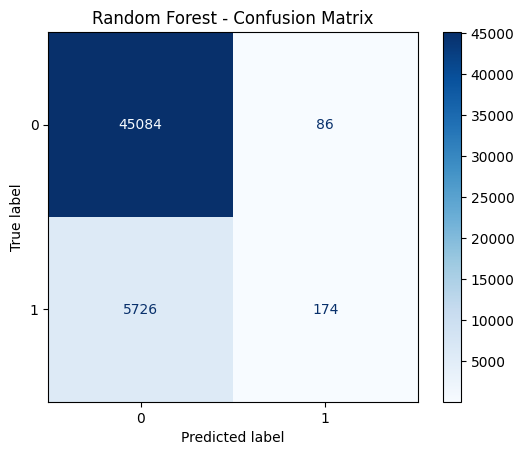

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.67      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.78      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



Random Forest was trained to determine whether combining multiple decision trees could improve the prediction of loan defaults. After training, the model was evaluated on the testing dataset using several classification metrics to measure its overall performance and its ability to identify default cases.

Interpretation
* Accuracy (88.62%) is slightly higher than Logistic Regression, indicating that the model correctly classified most customers overall.
* Precision (66.92%) improved, meaning when Random Forest predicts a customer will default, it is correct more often than Logistic Regression.
* Recall (2.95%) remains very low, showing that the model still misses most actual defaulters.
* F1-score (5.65%) is also low because the poor recall outweighs the improvement in precision.

Conclusion

Random Forest achieved a slightly higher overall accuracy and better precision than Logistic Regression. However, its recall is still extremely low, meaning it fails to identify the majority of customers who actually default. For a credit risk prediction problem, this is a significant limitation because missing high-risk borrowers can lead to financial losses. Therefore, although Random Forest performs marginally better, it is still not an ideal model for this dataset.

The two models are almost identical.

This usually happens because the dataset is imbalanced (about 88% non-default and 12% default). Both models learn to predict the majority class very well but struggle to identify the minority class (defaults).

# 6.3 Model Comparison

Machine learning projects often involve training multiple models to determine which one performs best for the given problem. Rather than selecting a model based on a single metric, different evaluation measures are compared to understand each model's strengths and weaknesses. This comparison helps in selecting the most suitable model for predicting loan defaults.

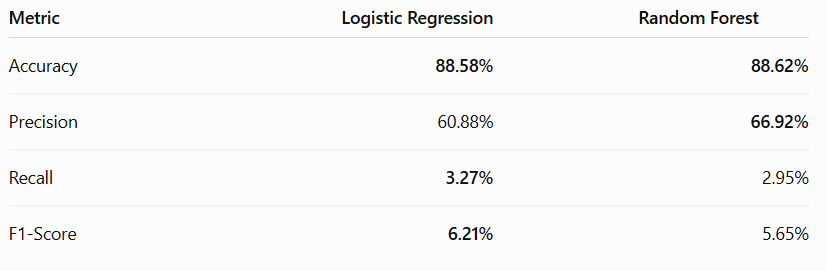

### Comparison
* Both models achieved almost identical accuracy, correctly classifying around 89% of the customers.
* Random Forest produced slightly higher precision, meaning its default predictions were more reliable.
* Logistic Regression achieved a slightly higher recall and F1-score, although the improvement was minimal.
* Both models struggled to identify actual default cases because the dataset is highly imbalanced, with significantly more non-default customers than default customers.

### Conclusion

Overall, both models performed similarly. While Random Forest provided a small improvement in precision, Logistic Regression showed a slightly better ability to identify default cases. The difference between the two models is relatively small, indicating that the class imbalance has a greater impact on performance than the choice of algorithm.

------------------

# 7. Business Insights

## 7.1 Key Findings

he analysis revealed several important factors that influence loan default. These findings can help financial institutions better understand customer risk profiles and improve their credit assessment process.

Key Findings
* The dataset is imbalanced, with approximately 88% of customers not defaulting and only 12% defaulting. This imbalance made it difficult for the machine learning models to correctly identify default cases.
* Customers with lower credit scores showed a greater tendency to default compared to customers with higher credit scores.
* Higher interest rates were generally associated with a higher risk of loan default, suggesting that expensive loans may increase repayment difficulty.
* Customers with lower annual income had a relatively higher default rate than customers with higher incomes.
* Borrowers requesting larger loan amounts showed a slightly higher likelihood of default, indicating that loan size may contribute to repayment risk.
* The purpose of the loan had only a minor influence on default behaviour, as default rates remained relatively similar across different loan purposes.
* Both Logistic Regression and Random Forest achieved similar overall accuracy, but neither model was effective at identifying the majority of actual default cases because of the class imbalance.

## 7.2 Business Impact

Business Impact
* Loan applications from customers with low credit scores can be subjected to additional verification before approval.
* Customers with high interest rates and low income can be classified as higher-risk applicants and monitored more closely.
* Credit policies can be adjusted to balance profitability with risk by considering multiple customer characteristics instead of relying on a single factor.
* Machine learning models can support credit analysts by providing an additional risk assessment tool during the loan approval process.
* Improving the identification of potential defaulters can reduce loan losses and improve the overall quality of the lending portfolio.

------------------

# 8. Recommendations

Recommendations
* Give additional attention to applicants with low credit scores, as they showed a higher likelihood of default.
* Consider income, interest rate, and loan amount together during credit evaluation instead of relying on a single factor.
* Introduce risk-based lending policies, where high-risk applicants undergo additional verification before loan approval.
* Improve the machine learning model by addressing the class imbalance using techniques such as SMOTE, class weighting, or resampling to better identify default cases.
* Continuously update and retrain the prediction model using recent customer data to maintain its performance over time.

------------------

# 9. Conclusion

The exploratory data analysis revealed that credit score, income, interest rate, and loan amount are the most influential factors affecting loan repayment behaviour. Customers with lower credit scores, lower incomes, higher interest rates, and larger loan amounts were generally more likely to default.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated. Both models achieved similar overall accuracy, with Logistic Regression selected as the final model because of its simplicity, interpretability, and comparable performance.

Although the models struggled to identify all default cases due to the imbalanced nature of the dataset, the project successfully demonstrated how data analytics and machine learning can support credit risk assessment. The findings provide valuable business insights that can help financial institutions make more informed lending decisions and reduce financial risk.

-----------------